# Scratch Contrastive Training — MLP / TCN / GCN

8개 reference dance(`404_dance, basic_movement, beginner_wave, cheerup_dance, hiphop_move, kpop_basic, rasputin, shuffle_dance`)에 대해 **MLP, TCN, GCN** 세 가지 인코더를 contrastive loss로 학습한다.

**샘플링 전략**
- anchor   = `reference.npy`의 t 시점 window (`T=30`프레임)
- positive = 같은 곡의 랜덤 `augment_data/aug_k.npy`의 같은 t
- negative = 다른 곡 (75%) 또는 같은 곡의 충분히 먼 t (25%) *(triplet 모드)*

**손실**
- InfoNCE (default): symmetric in-batch cross-entropy, temperature=0.1
- Triplet: cosine margin loss, margin=0.2

**학습 고도화**
- Warmup + cosine LR schedule, gradient clipping (norm=1.0)
- EarlyStopping (val_loss, patience=10, restore_best_weights)
- Hip-center/torso-scale normalization (translation+scale invariant)
- Positive temporal jitter (±2 프레임) — augment 외에 추가 robustness

모든 모델은 학습 후 **Keras + TFLite + metadata.json**으로 저장된다.

## 0. 환경 설정

In [1]:
import ctypes
import glob
import os

# --- TF GPU 활성화: pip-installed nvidia CUDA libs를 ctypes로 preload ---
# tensorflow import 전에 실행되어야 함. os.environ['LD_LIBRARY_PATH'] 방식은
# ld.so가 프로세스 시작 시점에 이미 캐시하므로 Jupyter에선 동작하지 않음.
_nv = '/workspace/users/yijin/boot_env/.venv/lib/python3.12/site-packages/nvidia'
if os.path.isdir(_nv):
    for _so in sorted(glob.glob(f'{_nv}/*/lib/*.so.*')):
        try:
            ctypes.CDLL(_so, mode=ctypes.RTLD_GLOBAL)
        except OSError:
            pass  # 이미 로드됐거나 심볼 충돌 — TF가 알아서 처리

import json
import sys
from argparse import Namespace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

start = Path.cwd().resolve()
PROJECT_ROOT = None
for base in [start, *start.parents]:
    if (base / 'data' / 'reference_dances').exists() and (base / 'src' / 'embedding' / 'models_scratch.py').exists():
        PROJECT_ROOT = base
        break
if PROJECT_ROOT is None:
    raise RuntimeError('pjt_re project root not found')
sys.path.insert(0, str(PROJECT_ROOT))

from src.embedding.dataset_contrastive import (
    ContrastiveBatchGenerator, ContrastiveSequenceStore, TARGET_DANCES,
)
from scripts.train_scratch_contrastive import train, parse_args

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print('PROJECT_ROOT:', PROJECT_ROOT)
print('TF version  :', tf.__version__)
print('GPU devices :', gpus if gpus else 'NONE (CPU fallback)')
print('TARGET_DANCES:', TARGET_DANCES)

I0000 00:00:1776691649.150612 1794379 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


PROJECT_ROOT: /workspace/users/yijin/boot_env/pjt_re
TF version  : 2.21.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TARGET_DANCES: ('404_dance', 'basic_movement', 'beginner_wave', 'cheerup_dance', 'hiphop_move', 'kpop_basic', 'rasputin', 'shuffle_dance')


## 1. 데이터 로드 체크

8개 곡 모두 `reference.npy` + `augment_data/aug_*.npy`가 준비돼 있는지 확인.

In [2]:
store = ContrastiveSequenceStore(
    PROJECT_ROOT / 'data' / 'reference_dances',
    dances=TARGET_DANCES, feature_dims=2, verbose=True,
)

info = pd.DataFrame([
    {'dance': b.name, 'T(frames)': b.num_frames, 'K(augments)': len(b.augments),
     'sample_shape': str(b.original.shape)}
    for b in store.bundles
])
info

[404_dance] T=568, augments=30
[basic_movement] T=476, augments=30
[beginner_wave] T=679, augments=30
[cheerup_dance] T=724, augments=30
[hiphop_move] T=792, augments=30
[kpop_basic] T=7164, augments=30
[rasputin] T=3147, augments=30
[shuffle_dance] T=1538, augments=30


,dance,T(frames),K(augments),sample_shape
0,404_dance,568,30,"(568, 12, 2)"
1,basic_movement,476,30,"(476, 12, 2)"
2,beginner_wave,679,30,"(679, 12, 2)"
3,cheerup_dance,724,30,"(724, 12, 2)"
4,hiphop_move,792,30,"(792, 12, 2)"
5,kpop_basic,7164,30,"(7164, 12, 2)"
6,rasputin,3147,30,"(3147, 12, 2)"
7,shuffle_dance,1538,30,"(1538, 12, 2)"


## 2. 샘플 배치 시각화

InfoNCE 배치가 의도대로 뽑히는지 확인. 같은 row의 anchor/positive는 같은 곡의 같은 시점, 다른 row는 다른 곡의 다른 시점.

anchor  : (4, 30, 12, 2)
positive: (4, 30, 12, 2)
negative: (4, 30, 12, 2)


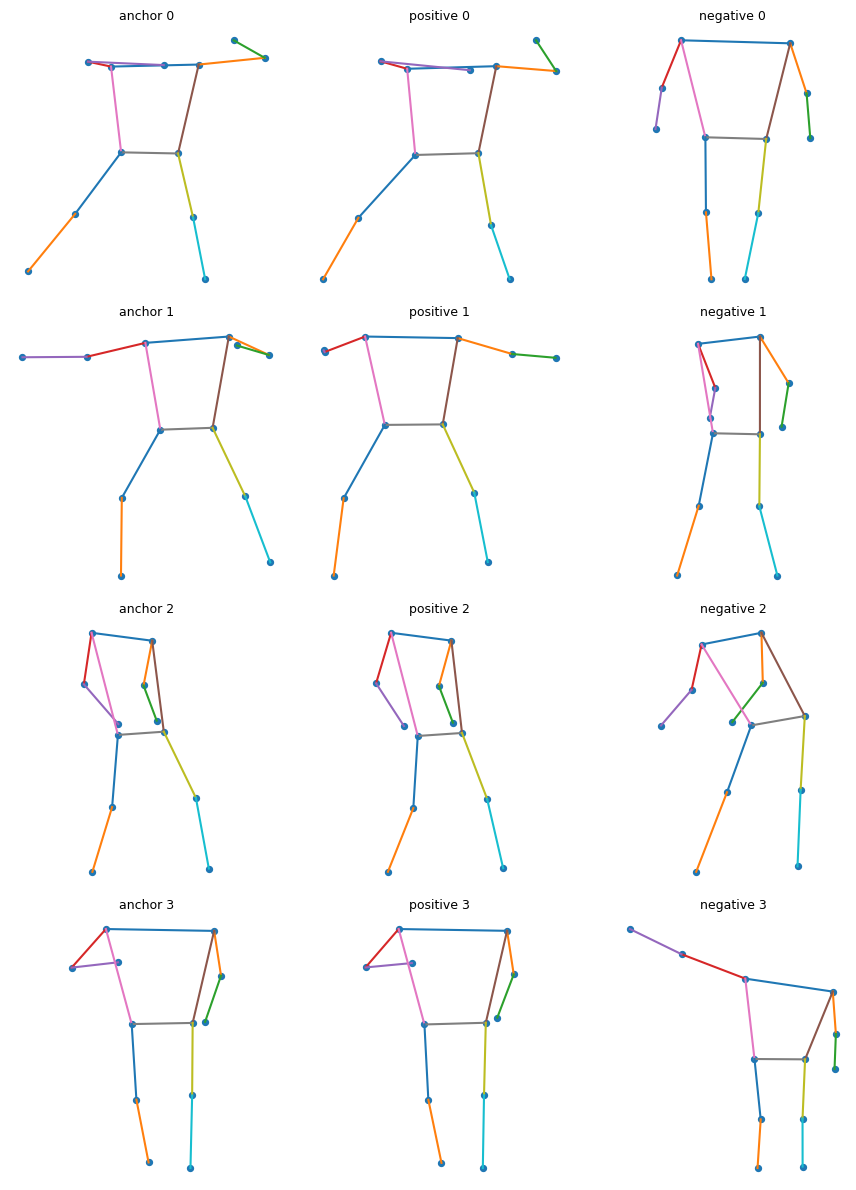

In [3]:
gen = ContrastiveBatchGenerator(store, sequence_length=30, batch_size=4,
                                 steps_per_epoch=1, mode='triplet',
                                 positive_jitter=2, negative_gap=45, seed=123)
(A, P, N), _ = next(gen.batches())
print('anchor  :', A.shape)
print('positive:', P.shape)
print('negative:', N.shape)

# 마지막 프레임만 스켈레톤 그리기
SKELETON_CONNECTIONS = [(0,1),(0,2),(2,4),(1,3),(3,5),(0,6),(1,7),(6,7),(6,8),(8,10),(7,9),(9,11)]

def draw(ax, pose, title):
    xs, ys = pose[:, 0], pose[:, 1]
    ax.scatter(xs, -ys, s=18)
    for a, b in SKELETON_CONNECTIONS:
        ax.plot([xs[a], xs[b]], [-ys[a], -ys[b]], lw=1.5)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(title, fontsize=9)

fig, axes = plt.subplots(4, 3, figsize=(9, 12))
for i in range(4):
    draw(axes[i, 0], A[i, -1], f'anchor {i}')
    draw(axes[i, 1], P[i, -1], f'positive {i}')
    draw(axes[i, 2], N[i, -1], f'negative {i}')
plt.tight_layout(); plt.show()

## 3. 공통 설정

모든 variants에 공통으로 적용될 기본 hyperparameter. 다음 cell의 `VARIANTS`에서
variant마다 override 가능.

In [4]:
COMMON = dict(
    data_dir='data/reference_dances',
    dances=list(TARGET_DANCES),
    output_dir='data/models/scratch',
    feature_dims=2,
    sequence_length=30,
    val_fraction=0.15,
    dropout=0.15,
    # training
    epochs=50,
    steps_per_epoch=200,
    validation_steps=30,
    batch_size=128,
    learning_rate=1e-3,
    min_learning_rate=1e-5,
    warmup_epochs=3,
    patience=10,
    temperature=0.1,
    triplet_margin=0.2,
    positive_jitter=2,
    negative_gap=300,
    runtime_jitter=0.005,    # on-the-fly Gaussian noise sigma (train only, 0=off)
    pretrained_weights=None, # from-scratch training (no pretrain load)
    seed=42,
    no_quantize=False,
    keep_checkpoint=False,
    verbose=2,
    # model-specific defaults (overridden per variant as needed)
    embedding_dim=64,
    mlp_hidden=128,
    tcn_filters=64, tcn_blocks=4, tcn_kernel=3,
    gcn_filters=64, gcn_blocks=3, gcn_kernel=9, gcn_partition='distance',
)

def run(**variant):
    """Train one variant; auto-generates model_name from tag/model/loss/dim."""
    cfg = {**COMMON, **variant}
    tag = cfg.pop('tag', None)
    cfg.pop('enabled', None)
    if cfg.get('model_name') is None:
        parts = [f"scratch_{cfg['model']}"]
        if tag:
            parts.append(tag)
        parts.append(cfg['loss'])
        parts.append(f"e{cfg['embedding_dim']}")
        cfg['model_name'] = '_'.join(parts)
    return train(Namespace(**cfg))

## 4. 학습할 variants 목록

각 아키텍처마다 3가지 조합:
- **small**: 용량 축소 (초경량 TFLite 타깃, 임베딩 32)
- **base**: 기본 InfoNCE (권장)
- **triplet**: base와 동일 구조의 Triplet 손실 비교

필요 없는 variant는 `enabled=False`로 두면 skip된다.
CPU 기준 하나당 ~20-40분. 9개 다 돌리면 밤새 돌려야 하니 필요한 것만 켤 것.

In [5]:
VARIANTS = [
    # ---- MLP ----
    {'enabled': True,  'model': 'mlp', 'loss': 'infonce', 'tag': 'small',
     'mlp_hidden': 64, 'embedding_dim': 32},
    {'enabled': True,  'model': 'mlp', 'loss': 'infonce', 'tag': 'base',
     'mlp_hidden': 128, 'embedding_dim': 64},
    {'enabled': True,  'model': 'mlp', 'loss': 'triplet', 'tag': 'small',
     'mlp_hidden': 64, 'embedding_dim': 32},
    {'enabled': True,  'model': 'mlp', 'loss': 'triplet', 'tag': 'base',
     'mlp_hidden': 128, 'embedding_dim': 64},
    # ---- TCN ----
    {'enabled': True,  'model': 'tcn', 'loss': 'infonce', 'tag': 'small',
     'tcn_filters': 32, 'tcn_blocks': 3, 'embedding_dim': 32},
    {'enabled': True,  'model': 'tcn', 'loss': 'infonce', 'tag': 'base',
     'tcn_filters': 64, 'tcn_blocks': 4, 'embedding_dim': 64},
    {'enabled': True,  'model': 'tcn', 'loss': 'triplet', 'tag': 'small',
     'tcn_filters': 32, 'tcn_blocks': 3, 'embedding_dim': 32},
    {'enabled': True,  'model': 'tcn', 'loss': 'triplet', 'tag': 'base',
     'tcn_filters': 64, 'tcn_blocks': 4, 'embedding_dim': 64},
    # ---- GCN ----
    {'enabled': True,  'model': 'gcn', 'loss': 'infonce', 'tag': 'small',
     'gcn_filters': 32, 'gcn_blocks': 2, 'embedding_dim': 32},
    {'enabled': True,  'model': 'gcn', 'loss': 'infonce', 'tag': 'base',
     'gcn_filters': 64, 'gcn_blocks': 3, 'embedding_dim': 64},
    {'enabled': True,  'model': 'gcn', 'loss': 'triplet', 'tag': 'small',
     'gcn_filters': 32, 'gcn_blocks': 2, 'embedding_dim': 32},
    {'enabled': True,  'model': 'gcn', 'loss': 'triplet', 'tag': 'base',
     'gcn_filters': 64, 'gcn_blocks': 3, 'embedding_dim': 64},
]

print(f"{'idx':>3} | {'model':>4} | {'loss':>8} | {'tag':>6} | {'dim':>4} | enabled")
print('-' * 50)
for i, v in enumerate(VARIANTS):
    print(f"{i:>3} | {v['model']:>4} | {v['loss']:>8} | {v.get('tag',''):>6} | {v['embedding_dim']:>4} | {v.get('enabled', True)}")
print(f"\nenabled count: {sum(v.get('enabled', True) for v in VARIANTS)} / {len(VARIANTS)}")


idx | model |     loss |    tag |  dim | enabled
--------------------------------------------------
  0 |  mlp |  infonce |  small |   32 | True
  1 |  mlp |  infonce |   base |   64 | True
  2 |  mlp |  triplet |  small |   32 | True
  3 |  mlp |  triplet |   base |   64 | True
  4 |  tcn |  infonce |  small |   32 | True
  5 |  tcn |  infonce |   base |   64 | True
  6 |  tcn |  triplet |  small |   32 | True
  7 |  tcn |  triplet |   base |   64 | True
  8 |  gcn |  infonce |  small |   32 | True
  9 |  gcn |  infonce |   base |   64 | True
 10 |  gcn |  triplet |  small |   32 | True
 11 |  gcn |  triplet |   base |   64 | True

enabled count: 12 / 12


## 5. 전체 variants 학습

`enabled=True`인 variant만 순차 학습. 하나 실패해도 다음 것은 계속 진행.
이미 학습된 variant(같은 `model_name`이 data/models/scratch/에 있는 경우)는 덮어쓴다.

In [6]:
import time, traceback

results = {}
enabled = [v for v in VARIANTS if v.get('enabled', True)]
t_total = time.time()

for i, v in enumerate(enabled):
    key = '_'.join(filter(None, [v['model'], v.get('tag'), v['loss']]))
    print(f"\n{'='*70}\n[{i+1}/{len(enabled)}] {key}\n{'='*70}")
    t0 = time.time()
    try:
        results[key] = run(**v)
        print(f"\n[done] {key} in {time.time()-t0:.1f}s | "
              f"tflite={results[key]['tflite_size_kib']:.1f} KiB")
    except Exception as exc:
        print(f"[FAIL] {key}: {type(exc).__name__}: {exc}")
        traceback.print_exc()

print(f"\n{'='*70}\nTotal: {len(results)}/{len(enabled)} succeeded in {(time.time()-t_total)/60:.1f} min")



[1/12] mlp_small_infonce
[404_dance] T=568, augments=30
[basic_movement] T=476, augments=30
[beginner_wave] T=679, augments=30
[cheerup_dance] T=724, augments=30
[hiphop_move] T=792, augments=30
[kpop_basic] T=7164, augments=30
[rasputin] T=3147, augments=30
[shuffle_dance] T=1538, augments=30
[DATA] 8 dances, feature_dims=2, val_fraction=0.15


I0000 00:00:1776691666.556523 1794379 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2331 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:0a:00.0, compute capability: 8.6


Model: "scratch_mlp_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pose (InputLayer)               │ (None, 30, 12, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_joints (Reshape)        │ (None, 30, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_dense_1 (Dense)           │ (None, 30, 64)         │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_bn_1 (BatchNormalization) │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_relu_1 (Activation)       │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_drop_1 (Dropout)          │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_dense_2 (Dense)           │ (None, 30, 64)         │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_bn_2 (BatchNormalization) │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_relu_2 (Activation)       │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_drop_2 (Dropout)          │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pool                   │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_hidden (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_raw (Dense)           │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Lambda)              │ (None, 32)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,408 (36.75 KB)

...

I0000 00:00:1776692596.812310 1794607 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_402984__.237
I0000 00:00:1776692614.814796 1794608 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_405197__.12


200/200 - 27s - 136ms/step - loss: 0.0082 - pos_margin: 0.8008 - val_loss: 0.0131 - val_pos_margin: 0.7081 - val_violation_rate: 0.1174 - violation_rate: 0.0777 - learning_rate: 3.3333e-04
Epoch 2/50
200/200 - 9s - 47ms/step - loss: 8.0491e-04 - pos_margin: 0.9006 - val_loss: 0.0097 - val_pos_margin: 0.6974 - val_violation_rate: 0.0802 - violation_rate: 0.0118 - learning_rate: 6.6667e-04
Epoch 3/50
200/200 - 9s - 47ms/step - loss: 6.5245e-04 - pos_margin: 0.8867 - val_loss: 0.0106 - val_pos_margin: 0.7203 - val_violation_rate: 0.0818 - violation_rate: 0.0110 - learning_rate: 0.0010
Epoch 4/50
200/200 - 9s - 47ms/step - loss: 4.6906e-04 - pos_margin: 0.8742 - val_loss: 0.0093 - val_pos_margin: 0.7304 - val_violation_rate: 0.0883 - violation_rate: 0.0076 - learning_rate: 0.0010
Epoch 5/50
200/200 - 9s - 47ms/step - loss: 4.1082e-04 - pos_margin: 0.8930 - val_loss: 0.0064 - val_pos_margin: 0.8197 - val_violation_rate: 0.0539 - violation_rate: 0.0069 - learning_rate: 9.9889e-04
Epoch 6/50


I0000 00:00:1776692813.521550 1794379 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1776692813.521649 1794379 single_machine.cc:376] Starting new session
I0000 00:00:1776692813.527190 1794379 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2331 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:0a:00.0, compute capability: 8.6
W0000 00:00:1776692813.709201 1794379 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1776692813.709233 1794379 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


[SAVE] encoder  : /workspace/users/yijin/boot_env/pjt_re/data/models/scratch/scratch_gcn_base_triplet_e64_encoder.keras
[SAVE] tflite   : /workspace/users/yijin/boot_env/pjt_re/data/models/scratch/scratch_gcn_base_triplet_e64.tflite (188.4 KiB)
[SAVE] metadata : /workspace/users/yijin/boot_env/pjt_re/data/models/scratch/scratch_gcn_base_triplet_e64_meta.json

[done] gcn_base_triplet in 225.2s | tflite=188.4 KiB

Total: 12/12 succeeded in 19.1 min


I0000 00:00:1776692813.769555 1794379 flatbuffer_export.cc:4302] Estimated count of arithmetic ops: 111.899 M  ops, equivalently 55.949 M  MACs


## 6. 전체 variants 비교

- **val_loss**: 낮을수록 좋음
- **val_retrieval_acc** (InfoNCE) / **val_pos_margin** (Triplet): 높을수록 좋음
- **tflite_KiB**: 배포 크기 (작을수록 좋음)
- **params**: 모델 파라미터 수

In [7]:
def _final(history, keys):
    for k in keys:
        if k in history and history[k]:
            return history[k][-1]
    return float('nan')

rows = []
for name, r in results.items():
    h = r['history']
    rows.append({
        'variant': name,
        'params': r['encoder'].count_params(),
        'tflite_KiB': round(r['tflite_size_kib'], 1),
        'val_loss': round(_final(h, ['val_loss']), 4),
        'val_metric': round(_final(h, ['val_retrieval_acc', 'val_pos_margin']), 4),
        'train_loss': round(_final(h, ['loss']), 4),
        'epochs_run': len(h.get('loss', [])),
    })
summary = pd.DataFrame(rows).sort_values('val_loss')
summary


,variant,params,tflite_KiB,val_loss,val_metric,train_loss,epochs_run
7,tcn_base_triplet,109632,126.7,0.0053,0.8356,0.0002,21
3,mlp_base_triplet,33152,40.5,0.0056,0.8987,0.0001,18
2,mlp_small_triplet,9408,15.0,0.0057,0.9026,0.0002,21
10,gcn_small_triplet,27680,47.7,0.0058,0.8976,0.0001,32
11,gcn_base_triplet,158528,188.4,0.0060,0.7995,0.0001,22
6,tcn_small_triplet,21728,34.1,0.0070,0.8379,0.0004,17
5,tcn_base_infonce,109632,126.7,0.0936,0.9974,0.0142,22
4,tcn_small_infonce,21728,34.1,0.1052,0.9995,0.0264,33
1,mlp_base_infonce,33152,40.5,0.1247,0.9992,0.0142,12
9,gcn_base_infonce,158528,188.4,0.1359,0.9961,0.0114,17


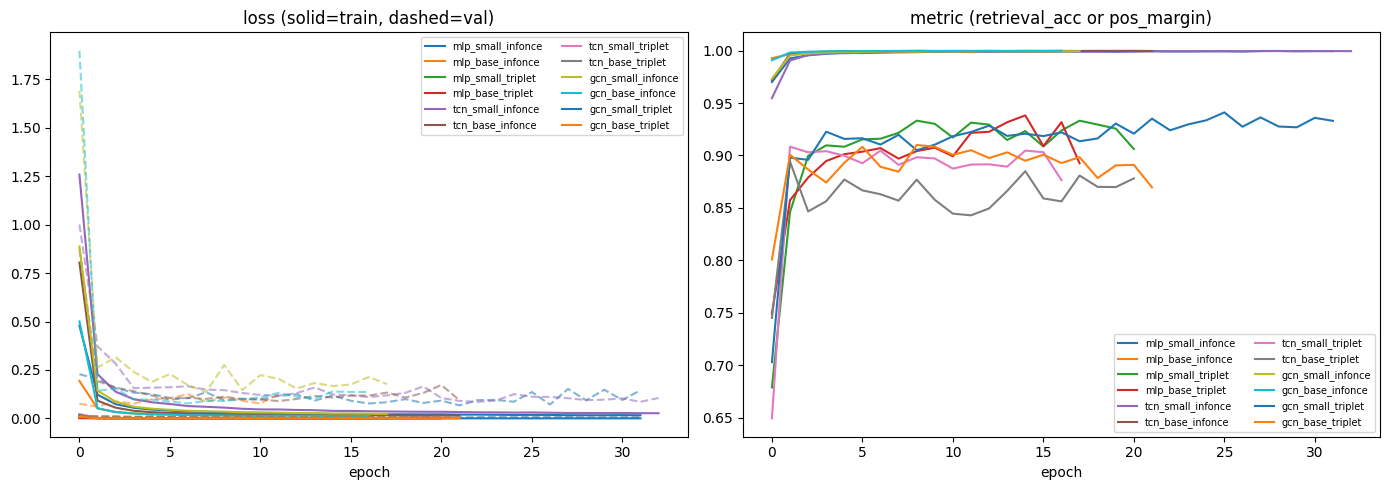

In [8]:
import itertools
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for (name, r), c in zip(results.items(), itertools.cycle(colors)):
    h = r['history']
    axes[0].plot(h['loss'], c=c, label=f'{name}')
    if 'val_loss' in h:
        axes[0].plot(h['val_loss'], c=c, ls='--', alpha=0.55)
    metric = 'retrieval_acc' if 'retrieval_acc' in h else 'pos_margin'
    if metric in h:
        axes[1].plot(h[metric], c=c, label=name)
axes[0].set_title('loss (solid=train, dashed=val)'); axes[0].set_xlabel('epoch')
axes[0].legend(fontsize=7, loc='upper right', ncol=2)
axes[1].set_title('metric (retrieval_acc or pos_margin)'); axes[1].set_xlabel('epoch')
axes[1].legend(fontsize=7, loc='lower right', ncol=2)
plt.tight_layout(); plt.show()


## 7. TFLite inference sanity check

학습한 모든 `.tflite`에 실제 reference 윈도우를 통과시켜 anchor-positive가
anchor-negative보다 cosine similarity가 높은지(=margin>0) 확인.

In [9]:
import tensorflow as tf

def tflite_embed(tflite_path, x):
    interp = tf.lite.Interpreter(model_path=str(tflite_path))
    interp.allocate_tensors()
    in_det = interp.get_input_details()[0]
    out_det = interp.get_output_details()[0]
    out = []
    for i in range(x.shape[0]):
        interp.set_tensor(in_det['index'], x[i:i+1].astype(in_det['dtype']))
        interp.invoke()
        out.append(interp.get_tensor(out_det['index'])[0])
    return np.stack(out)

eval_gen = ContrastiveBatchGenerator(
    store, sequence_length=COMMON['sequence_length'], batch_size=16,
    steps_per_epoch=1, mode='triplet', positive_jitter=0,
    negative_gap=COMMON['negative_gap'], seed=9999)
(A, P, N), _ = next(eval_gen.batches())

print(f"{'variant':30s} {'cos(a,p)':>10} {'cos(a,n)':>10} {'margin':>10}")
print('-' * 65)
for name, r in results.items():
    ea = tflite_embed(r['paths']['tflite'], A)
    ep = tflite_embed(r['paths']['tflite'], P)
    en = tflite_embed(r['paths']['tflite'], N)
    ap = (ea * ep).sum(-1).mean()
    an = (ea * en).sum(-1).mean()
    print(f"{name:30s} {ap:+10.4f} {an:+10.4f} {ap-an:+10.4f}")


variant                          cos(a,p)   cos(a,n)     margin
-----------------------------------------------------------------
mlp_small_infonce                 +0.9972    +0.0777    +0.9195
mlp_base_infonce                  +0.9934    +0.0814    +0.9121
mlp_small_triplet                 +0.9918    +0.1194    +0.8724
mlp_base_triplet                  +0.9940    +0.0946    +0.8994
tcn_small_infonce                 +0.9918    +0.0934    +0.8984
tcn_base_infonce                  +0.9950    +0.1066    +0.8884
tcn_small_triplet                 +0.9902    +0.1708    +0.8194
tcn_base_triplet                  +0.9893    +0.1550    +0.8343
gcn_small_infonce                 +0.9947    +0.0843    +0.9104
gcn_base_infonce                  +0.9953    +0.1420    +0.8533
gcn_small_triplet                 +0.9927    +0.1719    +0.8208


/workspace/users/yijin/boot_env/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


gcn_base_triplet                  +0.9931    +0.1862    +0.8069


## 완료

저장 위치: `data/models/scratch/`
- `{model_name}_encoder.keras`, `{model_name}.tflite`, `{model_name}_meta.json`

`model_name` 규칙: `scratch_{model}_{tag}_{loss}_e{embedding_dim}`
예: `scratch_tcn_base_infonce_e64.tflite`, `scratch_gcn_small_infonce_e32.tflite`

### 서비스에서 쓰려면
```bash
python src/main.py -s scratch \
    --compare data/reference_dances/rasputin/reference.npy \
    --scratch-model-path data/models/scratch/scratch_tcn_base_infonce_e64.tflite \
    --scratch-sequence-length 30 \
    --scratch-feature-dims 2 \
    --scratch-input-layout BTJC
```
